In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
data = load_diabetes()
x = data.data
y = data.target

In [3]:
print("X shape:", x.shape)
print("y shape:", y.shape)

X shape: (442, 10)
y shape: (442,)


### **Preprocess**

In [4]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train, x_cal, y_train, y_cal = train_test_split(x_train, y_train, test_size = 0.2, random_state=42)

# scaler is fitted ONLY using the proper training set
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
x_cal = scaler.transform(x_cal)


print("\nTraining samples:", len(x_train))
print("Calibration samples:", len(x_cal))
print("Test samples:", len(x_test))


Training samples: 282
Calibration samples: 71
Test samples: 89


In [5]:
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)

x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

x_cal_tensor = torch.tensor(x_cal, dtype=torch.float32)
y_cal_tensor = torch.tensor(y_cal, dtype=torch.float32).reshape(-1, 1)

### **NN model**

In [6]:
class RegressionNet(nn.Module):

    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)    # Point prediction
        )

    def forward(self, x):
        return self.network(x)

model = RegressionNet(input_dim=x_train.shape[1])
print("\nModel:")
print(model)


Model:
RegressionNet(
  (network): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [7]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

batch_size = 32
epochs = 100

In [8]:
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

#### **Training**

In [ ]:
history = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for x_batch, y_batch in train_loader:
        # Forward pass
        y_pred = model(x_batch)

        # Calculate loss
        loss = criterion(y_pred, y_batch)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    history.append(epoch_loss)

    if (epoch + 1) % 10 ==0:
        print(f"Epoch [{epoch + 1}/ {epochs}], " f"Loss: {epoch_loss:.4f}")

/home/ajf23/Documents/Coding new/University stuff/ADC2023/ADC2023-conformal-prediction/.venv/lib/python3.11/site-packages/torch/autograd/graph.py:979: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epich [10/ 100], Loss: 12194.9478
Epich [20/ 100], Loss: 3623.6600
Epich [30/ 100], Loss: 3145.5469
Epich [40/ 100], Loss: 2932.1429
Epich [50/ 100], Loss: 2799.1347
Epich [60/ 100], Loss: 2746.4499
Epich [70/ 100], Loss: 2665.5713
Epich [80/ 100], Loss: 2636.4150
Epich [90/ 100], Loss: 2595.0913
Epich [100/ 100], Loss: 2516.8114


#### **Calibration**

In [10]:
model.eval()

with torch.no_grad():
    y_cal_pred = model(x_cal_tensor).numpy().flatten()

# True calib labels
y_cal_numpy = y_cal_tensor.numpy().flatten()

#### **Calculate conformity scores**

In [11]:
calibration_scores = np.abs(y_cal_numpy - y_cal_pred)

print("\nNumber of calibration scores:", len(calibration_scores))

print("First 10 calibration scores:", calibration_scores[:10])


Number of calibration scores: 71
First 10 calibration scores: [93.77103    5.3916855 51.829315  74.79166   64.66237    2.787529
 64.978745  36.308548  42.562485  69.95776  ]


#### **Calculate conformal quantile**

In [12]:
alpha = 0.1 # Desired coverage = 90%

n_cal = len(calibration_scores)

# Finite sample conformal correction
k = int(np.ceil((n_cal + 1) * (1 - alpha)))

# k cannot exceed number of calibration points
k = min(k, n_cal)

# Sort conformity scores
sorted_scores = np.sort(calibration_scores)

q_hat = sorted_scores[k - 1] # Only need the -1 for python index start at zero
print("\nTarget coverage:", f"{100 * (1-alpha):.1f}%")
print("Conformal rank k:", k)
print("q_hat:", f"{q_hat:.4f}")


Target coverage: 90.0%
Conformal rank k: 65
q_hat: 87.1686


#### **Predict on test**

In [13]:
model.eval()
with torch.no_grad():
    y_test_pred = model(x_test_tensor).numpy().flatten()

#### **Construct conformal prediction intervals**

In [14]:
# C(x) = [f(x) - q_hat, f(x) + q_hat]

y_pred_lower = (y_test_pred - q_hat)
y_pred_upper = (y_test_pred + q_hat)

#### **Test coverage**

In [15]:
in_coverage = ((y_test >= y_pred_lower) & (y_test <= y_pred_upper))
coverage = np.mean(in_coverage)
print("\nEmpirical test coverage:", f"{100 * coverage:.2f}%")


Empirical test coverage: 87.64%


In [16]:
in_coverage

array([ True, False,  True,  True,  True,  True,  True, False,  True,
        True,  True,  True,  True, False,  True,  True,  True,  True,
        True,  True, False,  True,  True,  True,  True,  True,  True,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False,  True,  True, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True, False, False,
        True,  True,  True,  True,  True,  True, False,  True,  True,
        True,  True,  True,  True,  True,  True, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True])

In [17]:
interval_width = (y_pred_upper - y_pred_lower)
mean_interval_width = np.mean(interval_width)
print("Mean interval width:", f"{mean_interval_width:.4f}")

Mean interval width: 174.3372


In [18]:
print(interval_width) # As expected

[174.33716 174.33716 174.33716 174.33716 174.33716 174.33716 174.33716
 174.33716 174.33716 174.33716 174.33716 174.33716 174.33716 174.33714
 174.33716 174.33716 174.33716 174.33716 174.33716 174.33716 174.33717
 174.33716 174.33716 174.33716 174.33716 174.33716 174.33716 174.33714
 174.33716 174.33716 174.33716 174.33716 174.33716 174.33716 174.33716
 174.33716 174.33716 174.33716 174.33716 174.33716 174.33716 174.33716
 174.33716 174.33717 174.33716 174.33716 174.33716 174.33716 174.33716
 174.33716 174.33716 174.33716 174.33716 174.33716 174.33714 174.33716
 174.33716 174.33716 174.33716 174.33716 174.33716 174.33714 174.33716
 174.33716 174.33716 174.33716 174.33716 174.33716 174.33716 174.33716
 174.33716 174.33716 174.33716 174.33716 174.33716 174.33716 174.33716
 174.33716 174.33716 174.33717 174.33716 174.33716 174.33716 174.33716
 174.33716 174.33716 174.33716 174.33716 174.33716]


In [19]:
out_of_coverage_indices = np.where(~in_coverage)[0]
print("\nIndices outside conformal interval:", out_of_coverage_indices)


Indices outside conformal interval: [ 1  7 13 20 27 46 49 61 62 69 78]


#### **Batch by batch evaluation**

In [48]:
batch_size = 32
num_batches = int(np.ceil(len(x_test) / batch_size))


total_samples = 0
total_in_coverage = 0
total_interval_width = 0

with tqdm(total=num_batches, desc="Processing batches", unit="batch") as pbar:
    for batch_num, i in enumerate(range(0, len(x_test), batch_size)):
        batch_predictions = y_test_pred[i : i + batch_size]
        batch_labels = y_test[i : i + batch_size]
        #print("Predictions", batch_predictions)
        #print("Labels",batch_labels)
        # Construct conformal intervals
        lower = (batch_predictions - q_hat)
        upper = (batch_predictions + q_hat)

        # Coverage
        batch_in_coverage = ((batch_labels >= lower) & (batch_labels <= upper))
        num_in_coverage = np.sum(batch_in_coverage)

        widths = upper - lower
        batch_mean_width = np.mean(widths)

        total_samples += len(batch_labels)
        total_in_coverage += (num_in_coverage)
        total_interval_width += (batch_mean_width * len(batch_labels))

        coverage_percentage = (100 * total_in_coverage / total_samples)
        mean_interval_width_so_far = (total_interval_width / total_samples)

        pbar.set_postfix({
            "Batch number": batch_num + 1,
            "Coverage": f"{coverage_percentage:.2f}%",
            "Interval width": f"{mean_interval_width_so_far:.4f}",
            "Samples": total_samples
        })
        pbar.update(1)
print("--------------------")
print(f"\nCalibration threshold q_hat for {1 - alpha:.2f} coverage: {q_hat:.4f}")
print(f"Final Coverage: "
      f"{coverage_percentage:.2f}% "
      f"out of {total_samples} samples")
print(f"Final mean interval width: "
      f"{mean_interval_width_so_far:.4f}")

Processing batches: 100%|██████████| 3/3 [00:00<00:00, 631.55batch/s, Batch number=3, Coverage=87.64%, Interval width=174.3372, Samples=89]

--------------------

Calibration threshold q_hat for 0.90 coverage: 87.1686
Final Coverage: 87.64% out of 89 samples
Final mean interval width: 174.3372


#### **Plot subset**

In [29]:
n_samples = 50
start_index = 1
stop_index = start_index + n_samples

pred_subset = y_test_pred[start_index:stop_index]
y_subset = y_test[start_index:stop_index]

lower_subset = (pred_subset - q_hat)
upper_subset = (pred_subset + q_hat)

sample_indices = np.arange(start_index, stop_index)

#### **Plot conformal prediction intervals**

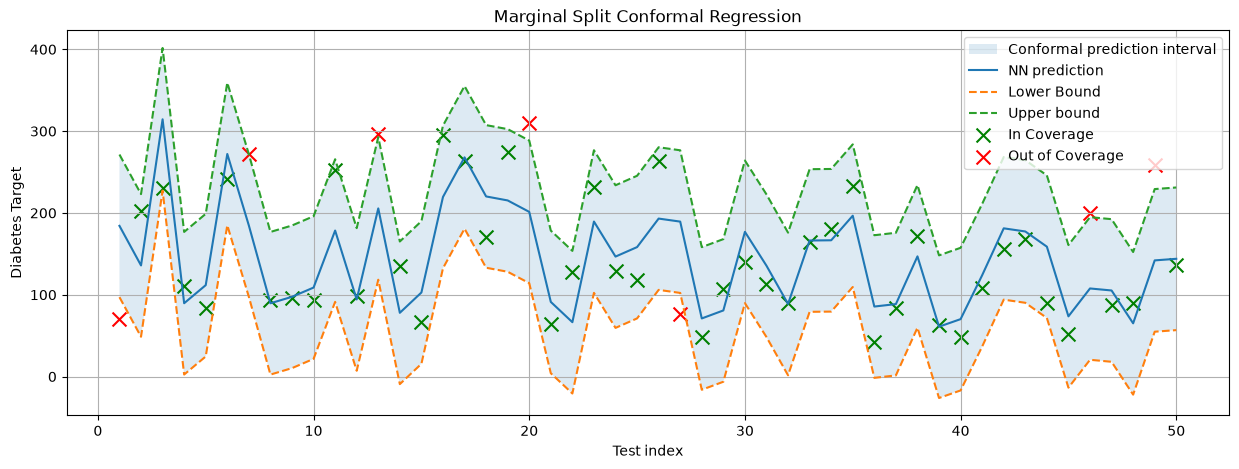

In [33]:
plt.figure(figsize = (15, 5))

#Conformal region
plt.fill_between(sample_indices,
                 lower_subset,
                 upper_subset,
                 alpha=0.15,
                 label = "Conformal prediction interval")

# NN prediction
plt.plot(sample_indices,
         pred_subset,
         label="NN prediction")

# Interval boundaries
plt.plot(sample_indices,
         lower_subset,
         linestyle="--",
         label="Lower Bound")

plt.plot(sample_indices,
         upper_subset,
         linestyle="--",
         label="Upper bound")

plt.scatter([], [], color='green', marker='x', s=100, label='In Coverage')
plt.scatter([], [], color='red', marker='x', s=100, label='Out of Coverage')

# Add true observations
for j, (index, true_value) in enumerate(zip(sample_indices, y_subset)):
    if (lower_subset[j] <= true_value <= upper_subset[j]):
        plt.scatter(index, true_value, color="green", marker="x", s=100)
    else:
        plt.scatter(index, true_value, color="red", marker="x", s=100)

plt.xlabel("Test index")
plt.ylabel("Diabetes Target")
plt.title("Marginal Split Conformal Regression")
plt.legend()
plt.grid(True)
#plt.xlim(start_index, stop_index -1)
plt.show()